<a href="https://colab.research.google.com/github/Series-Parallel/Machine_in_Deep_Learning/blob/main/Early_Exit_Monocular_Depth_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


resnet-18


In [2]:
class ResNet18Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Initial layers
        self.initial = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu
        )

        self.maxpool = resnet.maxpool

        # Encoder stages
        self.layer1 = resnet.layer1   # 64 channels
        self.layer2 = resnet.layer2   # 128 channels
        self.layer3 = resnet.layer3   # 256 channels
        self.layer4 = resnet.layer4   # 512 channels

    def forward(self, x):

        x0 = self.initial(x)      # H/2
        x1 = self.maxpool(x0)     # H/4

        x2 = self.layer1(x1)      # H/4
        x3 = self.layer2(x2)      # H/8
        x4 = self.layer3(x3)      # H/16
        x5 = self.layer4(x4)      # H/32

        return x0, x2, x3, x4, x5

In [3]:
encoder = ResNet18Encoder().to(device)

dummy = torch.randn(1, 3, 224, 224).to(device)

features = encoder(dummy)

for i, f in enumerate(features):
    print(f"Feature {i}: {f.shape}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 215MB/s]


Feature 0: torch.Size([1, 64, 112, 112])
Feature 1: torch.Size([1, 64, 56, 56])
Feature 2: torch.Size([1, 128, 28, 28])
Feature 3: torch.Size([1, 256, 14, 14])
Feature 4: torch.Size([1, 512, 7, 7])


decoder!!


In [4]:
class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):

        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)

        x = torch.cat([x, skip], dim=1)

        x = self.conv(x)

        return x

In [5]:
class DepthEstimationModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = ResNet18Encoder()

        self.up1 = UpBlock(512, 256, 256)
        self.up2 = UpBlock(256, 128, 128)
        self.up3 = UpBlock(128, 64, 64)
        self.up4 = UpBlock(64, 64, 32)

        # Exit 1
        self.depth_head1 = nn.Conv2d(256, 1, kernel_size=1)

        # Exit 2
        self.depth_head2 = nn.Conv2d(128, 1, kernel_size=1)

        # Final Exit
        self.depth_head3 = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):

        x0, x2, x3, x4, x5 = self.encoder(x)

        d1 = self.up1(x5, x4)
        d2 = self.up2(d1, x3)
        d3 = self.up3(d2, x2)
        d4 = self.up4(d3, x0)
      # Exit 1
        depth1 = self.depth_head1(d1)

        # Exit 2
        depth2 = self.depth_head2(d2)

        # Final Exit
        depth3 = self.depth_head3(d4)

        depth1 = F.interpolate(
            depth1,
            size=(224,224),
            mode='bilinear',
            align_corners=False
        )

        depth2 = F.interpolate(
            depth2,
            size=(224,224),
            mode='bilinear',
            align_corners=False
        )
        depth3 = F.interpolate(
            depth3,
            scale_factor=2,
            mode='bilinear',
            align_corners=False
        )

        return depth1, depth2, depth3

In [6]:
model = DepthEstimationModel().to(device)

dummy = torch.randn(1, 3, 224, 224).to(device)

depth1, depth2, depth3 = model(dummy)

print(depth1.shape)
print(depth2.shape)
print(depth3.shape)

torch.Size([1, 1, 224, 224])
torch.Size([1, 1, 224, 224])
torch.Size([1, 1, 224, 224])


testing this model on the real image


In [7]:
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [9]:
from google.colab import files

uploaded = files.upload()

Saving WhatsApp Image 2024-04-18 at 14.20.51_95d91a06.jpg to WhatsApp Image 2024-04-18 at 14.20.51_95d91a06.jpg


In [10]:
from PIL import ImageOps

image = Image.open(next(iter(uploaded)))
image = ImageOps.exif_transpose(image).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


In [11]:
model.eval()

with torch.no_grad():
    depth1, depth2, depth3 = model(input_tensor)

visualizing how the image looks, sounds interesting!


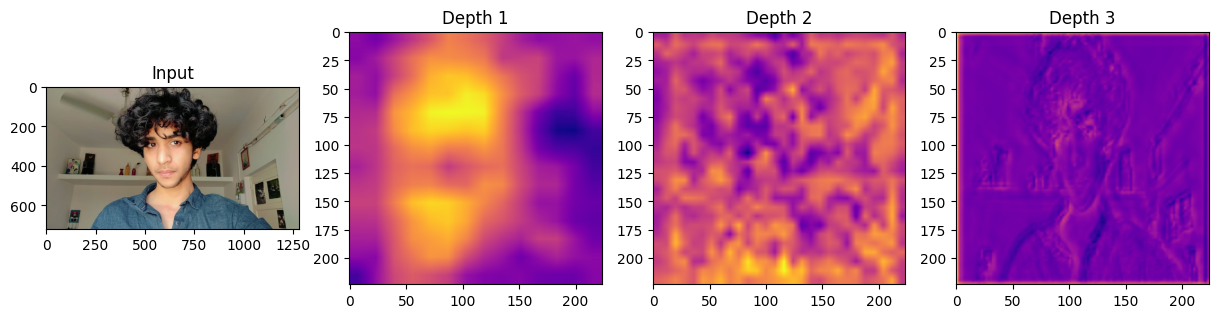

In [12]:
depth1_np = depth1.squeeze().cpu().numpy()
depth2_np = depth2.squeeze().cpu().numpy()
depth3_np = depth3.squeeze().cpu().numpy()

plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("Input")

plt.subplot(1,4,2)
plt.imshow(depth1_np, cmap="plasma")
plt.title("Depth 1")

plt.subplot(1,4,3)
plt.imshow(depth2_np, cmap="plasma")
plt.title("Depth 2")

plt.subplot(1,4,4)
plt.imshow(depth3_np, cmap="plasma")
plt.title("Depth 3")

plt.show()

### alright cool! we can see that depth 1 gave the worst depth map, then in depth 2 we can kinda figure out the border and everything but it is still shite! and finially in depth 3 we can easily see every boundaries, its not great but still a progress as we hvan't yet trained the model!

so now we will calculate the quality using the numbers!

In [13]:
delta12 = torch.mean(
    torch.abs(depth2 - depth1)
)

delta23 = torch.mean(
    torch.abs(depth3 - depth2)
)

print("Delta 1→2:", delta12.item())
print("Delta 2→3:", delta23.item())

Delta 1→2: 0.10053855180740356
Delta 2→3: 0.050911758095026016


In [14]:
import torch

print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_properties(0).total_memory / 1024**3, "GB")

Tesla T4
14.56317138671875 GB


#### setting up kaggle

In [15]:
!kaggle --version

Kaggle CLI 2.0.2


In [16]:
!kaggle datasets list -s nyu-depth-v2

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [17]:
mkdir -p ~/.kaggle && echo KGAT_623fde37a0b38d52a110f3df758e75e2 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [18]:
!kaggle datasets list -s nyu-depth-v2

ref                                                title                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------  ----------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
soumikrakshit/nyu-depth-v2                         NYU Depth V2                         4406701534  2021-03-07 15:48:46.607000          11503         64  0.625            
artemmmtry/nyu-depth-v2                            NYU Depth Dataset V2                34288053850  2024-08-12 12:32:31.167000           2256          4  1                
goubeast/nyuv2-depth                               NYU-v2 Depth                                 22  2021-10-27 15:41:35.713000            106          4  0.3125           
awsaf49/nyuv2-official-split-dataset               NYUv2: Official Split Dataset       28267558178  2023-01-27 17:07:49.410000            43

In [19]:
!kaggle datasets download -d soumikrakshit/nyu-depth-v2

Dataset URL: https://www.kaggle.com/datasets/soumikrakshit/nyu-depth-v2
License(s): unknown
100% 4.10G/4.10G [04:08<00:00, 17.8MB/s]



In [20]:
!unzip -q nyu-depth-v2.zip -d nyu_depth_v2

In [21]:
import os

for root, dirs, files in os.walk("nyu_depth_v2"):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-"*50)

    if len(root.split("/")) > 3:
        break

nyu_depth_v2
Folders: ['nyu_data']
Files: []
--------------------------------------------------
nyu_depth_v2/nyu_data
Folders: ['data']
Files: []
--------------------------------------------------
nyu_depth_v2/nyu_data/data
Folders: ['nyu2_test', 'nyu2_train']
Files: ['nyu2_test.csv', 'nyu2_train.csv']
--------------------------------------------------
nyu_depth_v2/nyu_data/data/nyu2_test
Folders: []
Files: ['00845_depth.png', '01090_colors.png', '00686_colors.png', '01130_colors.png', '00410_depth.png']
--------------------------------------------------


In [22]:
train_dir = "nyu_depth_v2/nyu_data/data/nyu2_train"

files = sorted(os.listdir(train_dir))

print(files[:20])

['basement_0001a_out', 'basement_0001b_out', 'bathroom_0001_out', 'bathroom_0002_out', 'bathroom_0005_out', 'bathroom_0006_out', 'bathroom_0007_out', 'bathroom_0010_out', 'bathroom_0011_out', 'bathroom_0013_out', 'bathroom_0014a_out', 'bathroom_0016_out', 'bathroom_0019_out', 'bathroom_0023_out', 'bathroom_0024_out', 'bathroom_0028_out', 'bathroom_0030_out', 'bathroom_0033_out', 'bathroom_0034_out', 'bathroom_0035_out']


In [23]:
train_dir = "nyu_depth_v2/nyu_data/data/nyu2_train"

first_scene = sorted(os.listdir(train_dir))[0]

print("Scene:", first_scene)

scene_path = os.path.join(train_dir, first_scene)

print("\nFiles inside scene:")
print(os.listdir(scene_path)[:20])

Scene: basement_0001a_out

Files inside scene:
['66.jpg', '21.png', '1.png', '118.jpg', '233.jpg', '50.jpg', '131.jpg', '137.png', '81.jpg', '118.png', '28.png', '276.jpg', '196.jpg', '90.jpg', '72.jpg', '213.png', '201.png', '281.jpg', '102.jpg', '99.jpg']


In [24]:
scene_path = os.path.join(
    train_dir,
    sorted(os.listdir(train_dir))[0]
)

jpgs = sorted([f for f in os.listdir(scene_path) if f.endswith(".jpg")])
pngs = sorted([f for f in os.listdir(scene_path) if f.endswith(".png")])

print("Number of JPGs:", len(jpgs))
print("Number of PNGs:", len(pngs))

print("\nFirst 10 JPGs:")
print(jpgs[:10])

print("\nFirst 10 PNGs:")
print(pngs[:10])

Number of JPGs: 281
Number of PNGs: 281

First 10 JPGs:
['1.jpg', '10.jpg', '100.jpg', '101.jpg', '102.jpg', '103.jpg', '104.jpg', '105.jpg', '106.jpg', '107.jpg']

First 10 PNGs:
['1.png', '10.png', '100.png', '101.png', '102.png', '103.png', '104.png', '105.png', '106.png', '107.png']


RGB size: (640, 480)
Depth size: (640, 480)


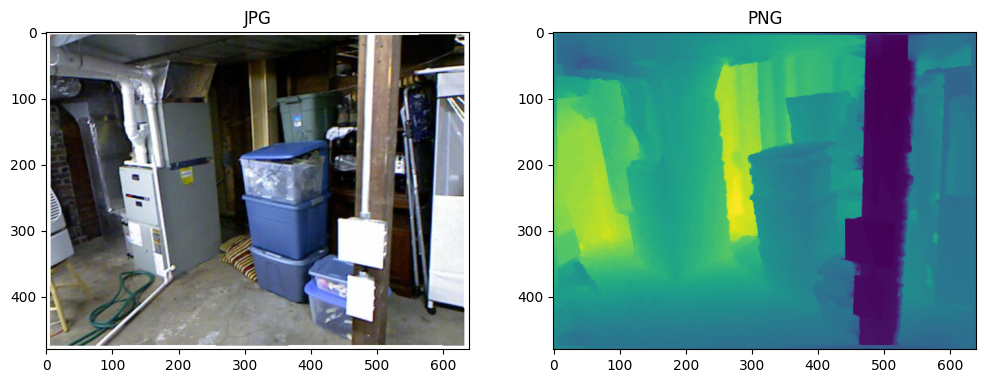

In [25]:
scene_path = os.path.join(
    train_dir,
    sorted(os.listdir(train_dir))[0]
)

sample_id = "118"   # we know both exist

rgb_path = os.path.join(scene_path, f"{sample_id}.jpg")
depth_path = os.path.join(scene_path, f"{sample_id}.png")

rgb = Image.open(rgb_path)
depth = Image.open(depth_path)

print("RGB size:", rgb.size)
print("Depth size:", depth.size)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title("JPG")

plt.subplot(1,2,2)
plt.imshow(depth)
plt.title("PNG")

plt.show()

In [26]:
import numpy as np

depth_np = np.array(depth)

print(depth_np.shape)
print(depth_np.dtype)
print("Min:", depth_np.min())
print("Max:", depth_np.max())

(480, 640)
uint8
Min: 21
Max: 120


In [27]:
depth_np = np.array(depth)

print(depth_np.shape)

(480, 640)


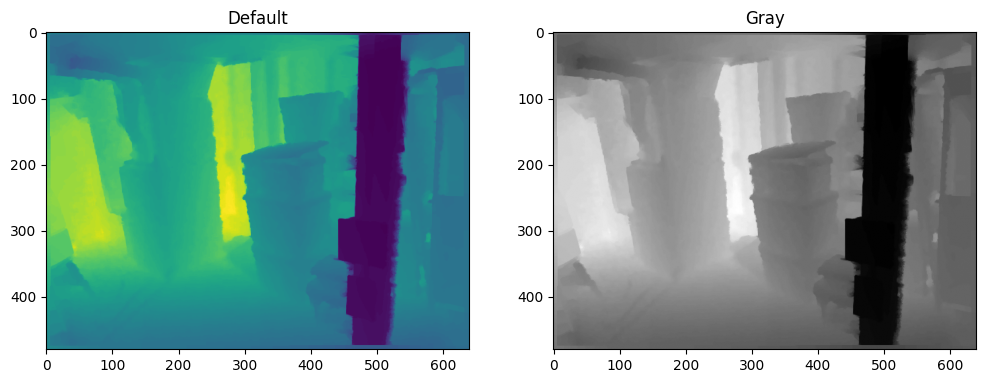

In [28]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(depth)
plt.title("Default")

plt.subplot(1,2,2)
plt.imshow(depth, cmap='gray')
plt.title("Gray")

plt.show()

In [29]:
depth_np = np.array(depth)

print("Shape:", depth_np.shape)
print("Dtype:", depth_np.dtype)

print(np.unique(depth_np[:10, :10]))

Shape: (480, 640)
Dtype: uint8
[57 64]


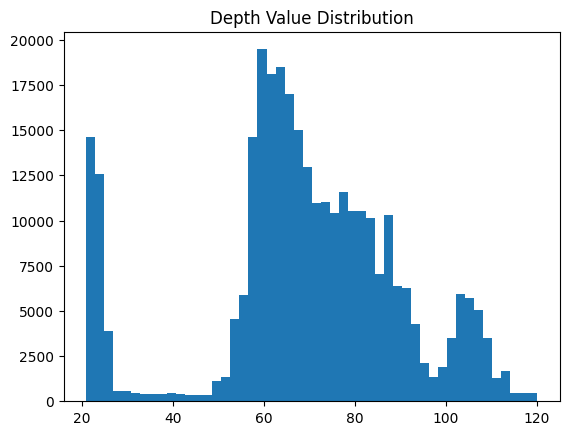

In [30]:
plt.hist(depth_np.flatten(), bins=50)
plt.title("Depth Value Distribution")
plt.show()

In [31]:
print(depth_np.dtype)
print(depth_np.min())
print(depth_np.max())

uint8
21
120


In [32]:
import os

train_dir = "nyu_depth_v2/nyu_data/data/nyu2_train"

rgb_files = []
depth_files = []

for scene in sorted(os.listdir(train_dir)):

    scene_path = os.path.join(train_dir, scene)

    if not os.path.isdir(scene_path):
        continue

    jpg_files = [f for f in os.listdir(scene_path) if f.endswith(".jpg")]

    for jpg in jpg_files:

        base_name = jpg.replace(".jpg", "")

        png = base_name + ".png"

        rgb_path = os.path.join(scene_path, jpg)
        depth_path = os.path.join(scene_path, png)

        if os.path.exists(depth_path):

            rgb_files.append(rgb_path)
            depth_files.append(depth_path)

print("RGB files:", len(rgb_files))
print("Depth files:", len(depth_files))

RGB files: 50688
Depth files: 50688


In [33]:
print(rgb_files[0])
print(depth_files[0])

print(rgb_files[1])
print(depth_files[1])

nyu_depth_v2/nyu_data/data/nyu2_train/basement_0001a_out/66.jpg
nyu_depth_v2/nyu_data/data/nyu2_train/basement_0001a_out/66.png
nyu_depth_v2/nyu_data/data/nyu2_train/basement_0001a_out/118.jpg
nyu_depth_v2/nyu_data/data/nyu2_train/basement_0001a_out/118.png


#### alright now we will use the dataset

In [34]:
from torch.utils.data import Dataset

In [35]:
class NYUDataset(Dataset):
    def __init__(self, rgb_files, depth_files):
        self.rgb_files = rgb_files
        self.depth_files = depth_files

        self.rgb_transform = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.rgb_files)

    def __getitem__(self, idx):

        rgb = Image.open(self.rgb_files[idx]).convert("RGB")
        depth = Image.open(self.depth_files[idx])

        rgb = self.rgb_transform(rgb)

        depth = depth.resize((224,224))
        depth = np.array(depth).astype(np.float32)

        # normalize to [0,1]
        depth = depth / 255.0

        depth = torch.tensor(depth).unsqueeze(0)

        return rgb, depth

In [36]:
dataset = NYUDataset(
    rgb_files,
    depth_files
)

print("Dataset size:", len(dataset))

Dataset size: 50688


In [37]:
image, depth = dataset[0]

print(image.shape)
print(depth.shape)

print(depth.min())
print(depth.max())

torch.Size([3, 224, 224])
torch.Size([1, 224, 224])
tensor(0.1176)
tensor(0.8000)


torch.Size([3, 224, 224])
torch.Size([1, 224, 224])


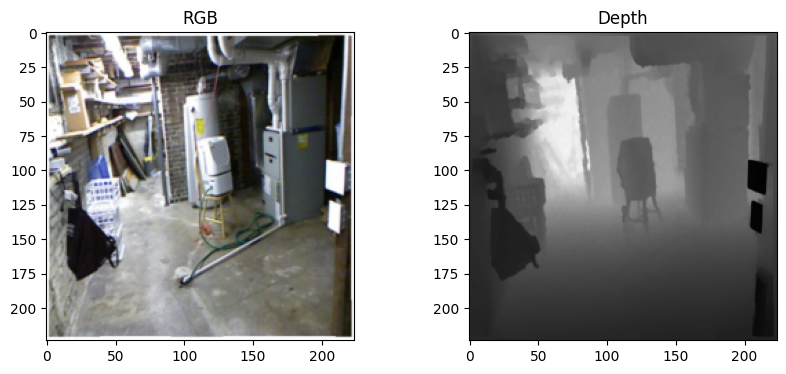

In [38]:
img, dep = dataset[0]

print(img.shape)
print(dep.shape)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))
plt.title("RGB")

plt.subplot(1,2,2)
plt.imshow(dep.squeeze(), cmap="gray")
plt.title("Depth")

plt.show()

In [39]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

images, depths = next(iter(train_loader))

print("Dataloader Shape:")
print(images.shape)
print(depths.shape)

Dataloader Shape:
torch.Size([8, 3, 224, 224])
torch.Size([8, 1, 224, 224])


In [40]:
images = images.to(device)

with torch.no_grad():
    depth1, depth2, depth3 = model(images)

print(depth1.shape)
print(depth2.shape)
print(depth3.shape)

torch.Size([8, 1, 224, 224])
torch.Size([8, 1, 224, 224])
torch.Size([8, 1, 224, 224])


### training!


In [41]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [42]:
model.train()

images = images.to(device)
depths = depths.to(device)

depth1, depth2, depth3 = model(images)

loss1 = criterion(depth1, depths)
loss2 = criterion(depth2, depths)
loss3 = criterion(depth3, depths)

loss = (
    0.2 * loss1 +
    0.3 * loss2 +
    0.5 * loss3
)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("Loss1:", loss1.item())
print("Loss2:", loss2.item())
print("Loss3:", loss3.item())
print("Total Loss:", loss.item())

Loss1: 0.24322213232517242
Loss2: 0.26655906438827515
Loss3: 0.3147003948688507
Total Loss: 0.2859623432159424


In [43]:
from torch.utils.data import Subset

small_dataset = Subset(
    dataset,
    range(1000)
)

train_loader = DataLoader(
    small_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

In [44]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

for epoch in range(2):

    model.train()

    running_loss = 0

    for images, depths in train_loader:

        images = images.to(device)
        depths = depths.to(device)

        depth1, depth2, depth3 = model(images)

        loss1 = criterion(depth1, depths)
        loss2 = criterion(depth2, depths)
        loss3 = criterion(depth3, depths)

        loss = (
            0.2 * loss1 +
            0.3 * loss2 +
            0.5 * loss3
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}: "
        f"{running_loss / len(train_loader):.4f}"
    )

Epoch 1: 0.0551
Epoch 2: 0.0316


In [45]:
model.eval()

img, gt_depth = dataset[3]

input_tensor = img.unsqueeze(0).to(device)

with torch.no_grad():
    d1, d2, d3 = model(input_tensor)

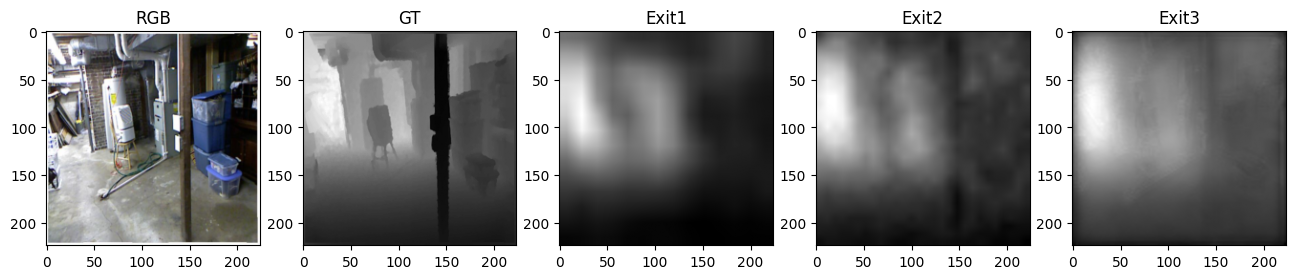

In [46]:
plt.figure(figsize=(16,4))

plt.subplot(1,5,1)
plt.imshow(img.permute(1,2,0))
plt.title("RGB")

plt.subplot(1,5,2)
plt.imshow(gt_depth.squeeze(), cmap="gray")
plt.title("GT")

plt.subplot(1,5,3)
plt.imshow(d1.squeeze().cpu(), cmap="gray")
plt.title("Exit1")

plt.subplot(1,5,4)
plt.imshow(d2.squeeze().cpu(), cmap="gray")
plt.title("Exit2")

plt.subplot(1,5,5)
plt.imshow(d3.squeeze().cpu(), cmap="gray")
plt.title("Exit3")

plt.show()

In [47]:
model.eval()

img, gt = dataset[3]

x = img.unsqueeze(0).to(device)

with torch.no_grad():

    d1, d2, d3 = model(x)

delta12 = torch.mean(
    torch.abs(d2 - d1)
)

delta23 = torch.mean(
    torch.abs(d3 - d2)
)

print("Delta12:", delta12.item())
print("Delta23:", delta23.item())

Delta12: 0.023000443354249
Delta23: 0.02200477384030819


alright so we can see that the delta mean got reduced, so we can say that the refinement magnitude is useful, but this is only 1 image and for 2 epochs we cant prove anything yet! we need to try this on more number of images!

In [48]:
def compute_deltas(model, dataset, num_samples=100):

    model.eval()

    deltas12 = []
    deltas23 = []

    with torch.no_grad():

        for i in range(num_samples):

            img, _ = dataset[i]

            x = img.unsqueeze(0).to(device)

            d1, d2, d3 = model(x)

            delta12 = torch.mean(
                torch.abs(d2 - d1)
            ).item()

            delta23 = torch.mean(
                torch.abs(d3 - d2)
            ).item()

            deltas12.append(delta12)
            deltas23.append(delta23)

    return deltas12, deltas23

In [49]:
d12, d23 = compute_deltas(
    model,
    dataset,
    num_samples=100
)

print("Mean Delta12:", np.mean(d12))
print("Mean Delta23:", np.mean(d23))

Mean Delta12: 0.019094433737918734
Mean Delta23: 0.01503647705540061


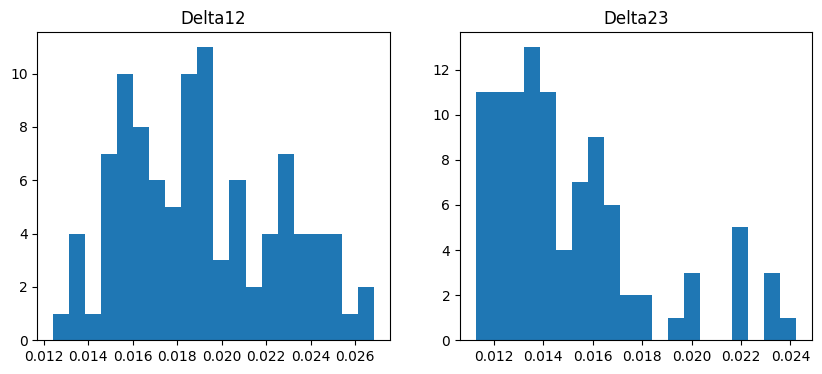

In [50]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(d12, bins=20)
plt.title("Delta12")

plt.subplot(1,2,2)
plt.hist(d23, bins=20)
plt.title("Delta23")

plt.show()

In [51]:
print("Delta12")
print("Min:", np.min(d12))
print("Max:", np.max(d12))
print("Std:", np.std(d12))

print()

print("Delta23")
print("Min:", np.min(d23))
print("Max:", np.max(d23))
print("Std:", np.std(d23))

Delta12
Min: 0.01243787631392479
Max: 0.02683272585272789
Std: 0.003436225264520242

Delta23
Min: 0.011285878717899323
Max: 0.024238692596554756
Std: 0.003138345174424608


#### alright we are done cooking that refinement is not increasing after deep exits so we need to prove that now! here we go

In [52]:
model.eval()

exit1_errors = []
exit2_errors = []
exit3_errors = []

with torch.no_grad():

    for i in range(100):

        img, gt_depth = dataset[i]

        img = img.unsqueeze(0).to(device)
        gt_depth = gt_depth.unsqueeze(0).to(device)

        d1, d2, d3 = model(img)

        err1 = torch.mean(
            torch.abs(d1 - gt_depth)
        ).item()

        err2 = torch.mean(
            torch.abs(d2 - gt_depth)
        ).item()

        err3 = torch.mean(
            torch.abs(d3 - gt_depth)
        ).item()

        exit1_errors.append(err1)
        exit2_errors.append(err2)
        exit3_errors.append(err3)

In [53]:
print("Exit1 Mean Error:", np.mean(exit1_errors))
print("Exit2 Mean Error:", np.mean(exit2_errors))
print("Exit3 Mean Error:", np.mean(exit3_errors))

Exit1 Mean Error: 0.040536969490349295
Exit2 Mean Error: 0.03543713703751564
Exit3 Mean Error: 0.039557725321501494


/tmp/ipykernel_3239/2284168921.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


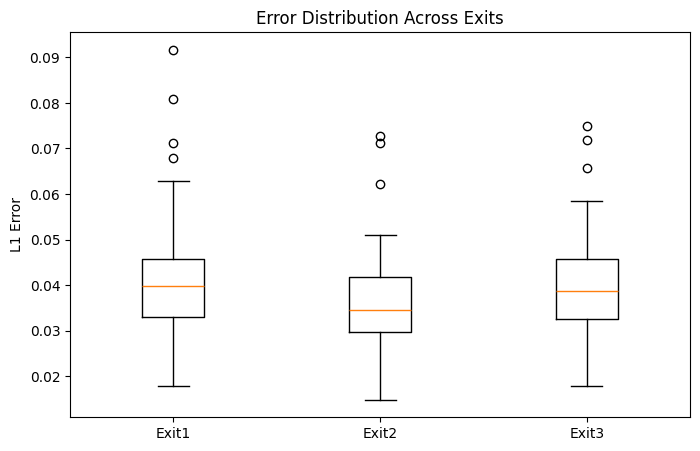

In [54]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        exit1_errors,
        exit2_errors,
        exit3_errors
    ],
    labels=["Exit1","Exit2","Exit3"]
)

plt.ylabel("L1 Error")
plt.title("Error Distribution Across Exits")

plt.show()

okay now I've hit a pause! Because i expected that exit 3 would have nice refinement but seems like exit 2 is better so i need to train the model further for more epochs so i can get the assuracne about whats right and whats wrong!

In [56]:
import random

In [57]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed fixed:", SEED)

Seed fixed: 42


In [58]:
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    small_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    generator=g
)

In [59]:
torch.save(
    model.state_dict(),
    "multi_exit_depth_epoch5.pth"
)

print("Model saved!")

Model saved!


In [60]:
from google.colab import files

files.download("multi_exit_depth_epoch5.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [63]:
model.load_state_dict(
    torch.load("multi_exit_depth_epoch5.pth")
)

<All keys matched successfully>

In [64]:
torch.save({
    'epoch': 5,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}, "checkpoint_epoch5.pth")

In [65]:
checkpoint = torch.load("checkpoint_epoch5.pth")

model.load_state_dict(
    checkpoint['model_state_dict']
)

optimizer.load_state_dict(
    checkpoint['optimizer_state_dict']
)

start_epoch = checkpoint['epoch']

In [66]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, depths in train_loader:

        images = images.to(device)
        depths = depths.to(device)

        depth1, depth2, depth3 = model(images)

        loss1 = criterion(depth1, depths)
        loss2 = criterion(depth2, depths)
        loss3 = criterion(depth3, depths)

        loss = (
            0.2 * loss1 +
            0.3 * loss2 +
            0.5 * loss3
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {avg_loss:.4f}"
    )

Epoch [1/5] Loss: 0.0254
Epoch [2/5] Loss: 0.0209
Epoch [3/5] Loss: 0.0173
Epoch [4/5] Loss: 0.0158
Epoch [5/5] Loss: 0.0148


In [67]:
torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}, "checkpoint_epoch5.pth")

print("Checkpoint Saved!")

Checkpoint Saved!


In [68]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [71]:
torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
},
"/content/drive/MyDrive/checkpoint_epoch5.pth")

running those exit values again

In [70]:
model.eval()

exit1_errors = []
exit2_errors = []
exit3_errors = []

with torch.no_grad():

    for i in range(100):

        img, gt_depth = dataset[i]

        img = img.unsqueeze(0).to(device)
        gt_depth = gt_depth.unsqueeze(0).to(device)

        d1, d2, d3 = model(img)

        err1 = torch.mean(
            torch.abs(d1 - gt_depth)
        ).item()

        err2 = torch.mean(
            torch.abs(d2 - gt_depth)
        ).item()

        err3 = torch.mean(
            torch.abs(d3 - gt_depth)
        ).item()

        exit1_errors.append(err1)
        exit2_errors.append(err2)
        exit3_errors.append(err3)

In [72]:
print("Exit1 Mean Error:", np.mean(exit1_errors))
print("Exit2 Mean Error:", np.mean(exit2_errors))
print("Exit3 Mean Error:", np.mean(exit3_errors))

Exit1 Mean Error: 0.027041069269180297
Exit2 Mean Error: 0.01996686060912907
Exit3 Mean Error: 0.02329153846949339


/tmp/ipykernel_3239/2284168921.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


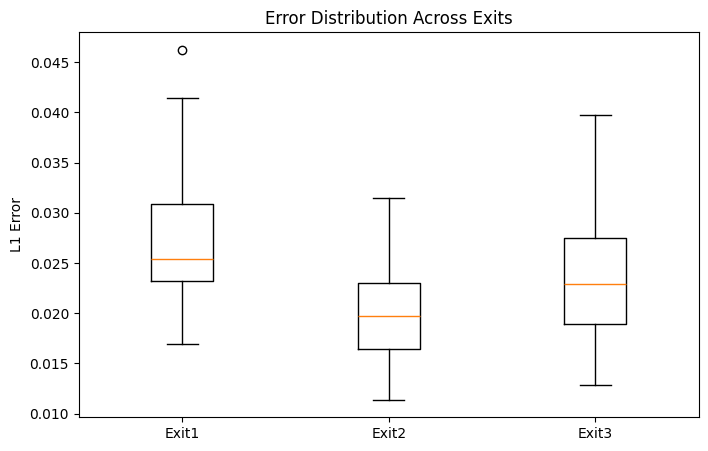

In [73]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        exit1_errors,
        exit2_errors,
        exit3_errors
    ],
    labels=["Exit1","Exit2","Exit3"]
)

plt.ylabel("L1 Error")
plt.title("Error Distribution Across Exits")

plt.show()

alright will run it again for 10 epochs now!


In [74]:
def train_model(model,
                train_loader,
                optimizer,
                criterion,
                device,
                num_epochs):

    for epoch in range(num_epochs):

        model.train()

        running_loss = 0

        for images, depths in train_loader:

            images = images.to(device)
            depths = depths.to(device)

            d1, d2, d3 = model(images)

            loss1 = criterion(d1, depths)
            loss2 = criterion(d2, depths)
            loss3 = criterion(d3, depths)

            loss = (
                0.2 * loss1 +
                0.3 * loss2 +
                0.5 * loss3
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Loss: {avg_loss:.4f}"
        )

should've done this earlier only :P

In [75]:
checkpoint = torch.load("checkpoint_epoch5.pth")

model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

In [76]:
train_model(
    model,
    train_loader,
    optimizer,
    criterion,
    device,
    num_epochs=5
)

Epoch [1/5] Loss: 0.0140
Epoch [2/5] Loss: 0.0127
Epoch [3/5] Loss: 0.0122
Epoch [4/5] Loss: 0.0133
Epoch [5/5] Loss: 0.0119


In [77]:
model.eval()

exit1_errors = []
exit2_errors = []
exit3_errors = []

with torch.no_grad():

    for i in range(100):

        img, gt_depth = dataset[i]

        img = img.unsqueeze(0).to(device)
        gt_depth = gt_depth.unsqueeze(0).to(device)

        d1, d2, d3 = model(img)

        err1 = torch.mean(
            torch.abs(d1 - gt_depth)
        ).item()

        err2 = torch.mean(
            torch.abs(d2 - gt_depth)
        ).item()

        err3 = torch.mean(
            torch.abs(d3 - gt_depth)
        ).item()

        exit1_errors.append(err1)
        exit2_errors.append(err2)
        exit3_errors.append(err3)

print("===== 10 Epoch Results =====")
print("Exit1 Mean Error:", np.mean(exit1_errors))
print("Exit2 Mean Error:", np.mean(exit2_errors))
print("Exit3 Mean Error:", np.mean(exit3_errors))

===== 10 Epoch Results =====
Exit1 Mean Error: 0.021821363968774675
Exit2 Mean Error: 0.01589864006265998
Exit3 Mean Error: 0.014533685790374874


/tmp/ipykernel_3239/2973535369.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


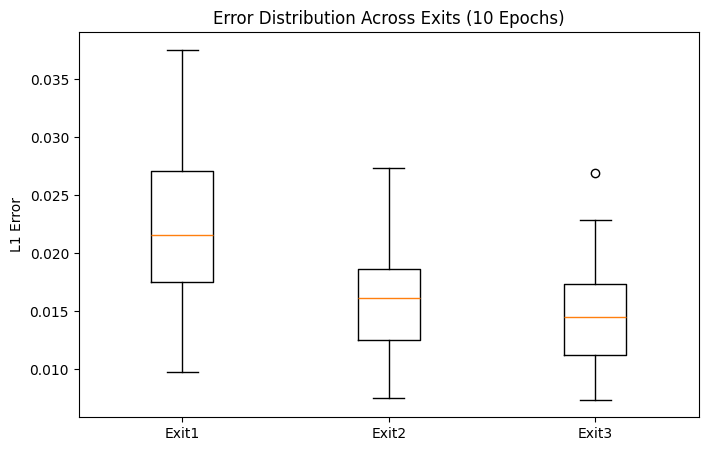

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(
    [
        exit1_errors,
        exit2_errors,
        exit3_errors
    ],
    labels=["Exit1","Exit2","Exit3"]
)

plt.ylabel("L1 Error")
plt.title("Error Distribution Across Exits (10 Epochs)")

plt.show()

In [79]:
def compute_deltas(model, dataset, num_samples=100):

    model.eval()

    deltas12 = []
    deltas23 = []

    with torch.no_grad():

        for i in range(num_samples):

            img, _ = dataset[i]

            x = img.unsqueeze(0).to(device)

            d1, d2, d3 = model(x)

            delta12 = torch.mean(
                torch.abs(d2 - d1)
            ).item()

            delta23 = torch.mean(
                torch.abs(d3 - d2)
            ).item()

            deltas12.append(delta12)
            deltas23.append(delta23)

    return deltas12, deltas23

In [80]:
d12, d23 = compute_deltas(
    model,
    dataset,
    num_samples=100
)

In [81]:
print("===== 10 Epoch Delta Results =====")

print("Mean Delta12:", np.mean(d12))
print("Mean Delta23:", np.mean(d23))

print("\nDelta12")
print("Min:", np.min(d12))
print("Max:", np.max(d12))
print("Std:", np.std(d12))

print("\nDelta23")
print("Min:", np.min(d23))
print("Max:", np.max(d23))
print("Std:", np.std(d23))

===== 10 Epoch Delta Results =====
Mean Delta12: 0.01424945132341236
Mean Delta23: 0.007893119221553207

Delta12
Min: 0.007192379329353571
Max: 0.02464807778596878
Std: 0.003940537592174298

Delta23
Min: 0.0052153305150568485
Max: 0.01108575239777565
Std: 0.0014963523612167488
